Import Libraries

In [59]:
import ultralytics
import supervision
import torch
import cv2
from collections import defaultdict
import supervision as sv
from ultralytics import YOLO
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

Define Model

In [60]:
model = YOLO("yolov8n.pt")
results = model("https://ultralytics.com/images/bus.jpg")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/calebfree/Documents/Development/Comp590/CV_Project/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 31.7ms
Speed: 1.3ms preprocess, 31.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)


Print Results

bus
tensor([[ 22.8713, 231.2773, 805.0026, 756.8405]])
person
tensor([[ 48.5504, 398.5522, 245.3456, 902.7027]])
person
tensor([[669.4729, 392.1861, 809.7202, 877.0355]])
person
tensor([[221.5173, 405.7986, 344.9706, 857.5366]])
person
tensor([[  0.0000, 550.5250,  63.0069, 873.4429]])
stop sign
tensor([[5.8174e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02]])
['bus', 'person', 'person2', 'person3', 'person4', 'stop sign']
[0.873448371887207, 0.8656911849975586, 0.8528353571891785, 0.8252245187759399, 0.26111215353012085, 0.2550683617591858]


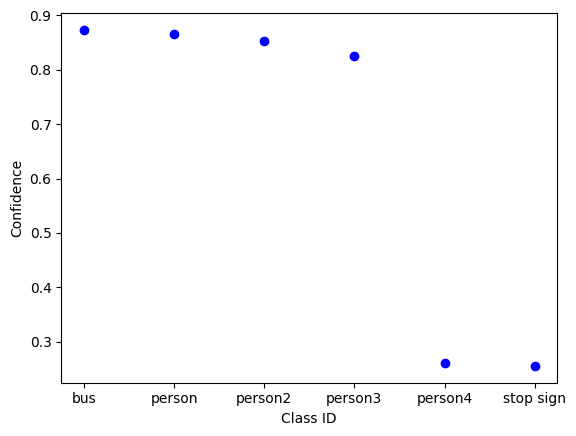

In [61]:
for result in results:
    result.show()
    box_labels = []
    box_confs = []
    for box in result.boxes:
        box_label = result.names[int(box.cls[0])]
        i = 2
        while box_label in box_labels:
            box_label = result.names[int(box.cls[0])] + str(i)
            i += 1
        box_labels.append(box_label)
        box_confs.append(float(box.conf[0]))
        print(result.names[int(box.cls[0])])
        print(box.xyxy)
    print(box_labels)
    print(box_confs)
    fig, ax = plt.subplots()
    ax.scatter(box_labels, box_confs, color="blue", marker='o')
    ax.set_xlabel("Class ID")
    ax.set_ylabel("Confidence")

Plot Certainty Values

In [62]:
plt.show()